# Valuation model

Training lives in `src/carval/train.py` and writes `reports/metrics.json` plus the test-set predictions. This notebook checks those numbers, refits only the make-model median baseline on the same split, and runs a few listings through `predict_car`.

In [1]:
import json

import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.model_selection import train_test_split

from carval.config import (
    FEATURE_COLUMNS,
    FIGURES,
    PROCESSED_CSV,
    RANDOM_STATE,
    REPORTS,
    TEST_SIZE,
)
from carval.evaluate import regression_metrics
from carval.features import add_features
from carval.predict import predict_car
from carval.train import MakeModelMedian

metrics = json.loads((REPORTS / "metrics.json").read_text())
pred = pd.read_csv(REPORTS / "test_predictions.csv")
comparison = pd.DataFrame(metrics["comparison"])[
    ["model", "cv_mae_mean", "cv_mae_std"]
].sort_values("cv_mae_mean")
comparison

,model,cv_mae_mean,cv_mae_std
0,xgboost,3.925948,0.080813
1,lightgbm,4.222435,0.234143
2,catboost,4.381155,0.174699
3,hist_gradient_boosting,4.396066,0.182895
4,ridge,6.538009,0.216923
5,random_forest,7.934683,0.233588
6,median_make_model,13.649235,0.219422


Cross-validated MAE is in lakh PKR. XGBoost is ahead of the other trees, and all of them beat ridge and the median baseline. The fold standard deviation on XGBoost is about 0.08 lakh, so the gap over LightGBM is not one lucky fold.

In [2]:
actual = pred["actual"].to_numpy()
point = pred["predicted"].to_numpy()
ape = np.abs(point - actual) / actual
within_10 = float(np.mean(ape <= 0.10))
within_20 = float(np.mean(ape <= 0.20))
covered = (actual >= pred["low"]) & (actual <= pred["high"])
width = pred["high"] - pred["low"]
print(f"test rows {len(pred)}")
print(f"MAE {np.mean(np.abs(point - actual)):.2f} lakh")
print(f"median APE {np.median(ape) * 100:.1f}%")
print(f"within 10% {within_10 * 100:.1f}%   within 20% {within_20 * 100:.1f}%")
print(f"interval coverage {covered.mean() * 100:.1f}%")
print(f"mean width {width.mean():.1f} lakh   median width {width.median():.1f}")
print(f"mean width / price {np.mean(width / actual):.3f}")

test rows 10294
MAE 3.75 lakh
median APE 6.6%
within 10% 65.6%   within 20% 87.8%
interval coverage 80.5%
mean width 11.9 lakh   median width 8.9
mean width / price 0.315


On the untouched test set the typical error is about 6.6% and 88% of predictions land within 20% of the asking price. The conformal band, fit on out-of-fold log residuals only, covers 80.5% of test prices. We did not change the band after seeing that number. Mean width is 11.9 lakh, about 32% of the price, and it scales with the price because the residual is in log space.

In [3]:
clean = pd.read_csv(PROCESSED_CSV)
featured = add_features(clean)
X = featured[FEATURE_COLUMNS].reset_index(drop=True)
y = np.log1p(featured["price_lakh"].to_numpy(dtype=float))
bins = pd.qcut(featured["price_lakh"], q=5, labels=False, duplicates="drop").to_numpy()
index = np.arange(len(X))
train_idx, test_idx = train_test_split(
    index, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=bins
)
baseline = MakeModelMedian().fit(X.iloc[train_idx], y[train_idx])
baseline_hat = baseline.predict(X.iloc[test_idx])
baseline_metrics = regression_metrics(y[test_idx], baseline_hat)
print(f"median baseline test MAE {baseline_metrics['mae_lakh']:.2f} lakh")
print(f"saved baseline MAE {metrics['baseline_test']['mae_lakh']:.2f} lakh")
print(f"saved XGBoost MAE {metrics['test']['mae_lakh']:.2f} lakh")

median baseline test MAE 13.27 lakh
saved baseline MAE 13.27 lakh
saved XGBoost MAE 3.75 lakh


The median of the same make and model, fit only on the training side of this split, misses by about 13 lakh. XGBoost misses by about 3.7. The saved baseline figure matches this refit, so the split in the report is the split above.

In [4]:
segments = pd.read_csv(REPORTS / "segment_errors.csv")
keep = segments["segment"].isin(["price_bucket", "age_bucket", "fuel"])
view = segments.loc[keep, ["segment", "level", "n", "mae_lakh", "median_ape", "within_20pct"]]
view = view.assign(
    mae_lakh=lambda d: d["mae_lakh"].round(2),
    median_ape=lambda d: (d["median_ape"] * 100).round(1),
    within_20pct=lambda d: (d["within_20pct"] * 100).round(1),
)
view

,segment,level,n,mae_lakh,median_ape,within_20pct
9,price_bucket,budget,3194,1.79,10.6,76.2
10,price_bucket,mid,5423,2.68,5.6,93.5
11,price_bucket,premium,1677,10.93,5.2,91.5
12,fuel,CNG,71,1.40,11.9,78.9
13,fuel,Diesel,392,7.23,9.7,73.5
14,fuel,Electric,34,44.79,11.8,67.6
15,fuel,Hybrid,717,6.03,6.0,93.0
16,fuel,LPG,13,1.41,20.7,46.2
17,fuel,Petrol,9067,3.28,6.5,88.2
18,age_bucket,0-4,2604,4.38,4.3,96.8


Median percentage error is about 5% on mid and premium cars and about 11% on budget cars. Cars under five years old are within 20% almost all of the time. Cars 20 years and older are not. Electric is 34 test rows and a large MAE. LPG is 13 rows. Those slices are too thin to trust a single number.

In [5]:
labels = pd.Series(metrics["deal_labels_oof"])
print((labels / labels.sum() * 100).round(1).sort_values(ascending=False).to_string())
print("perturbation accuracy", round(metrics["perturbation"]["accuracy"], 3))
print("perturbation macro F1", round(metrics["perturbation"]["macro_f1"], 3))

FAIR           66.0
OVERPRICED     18.1
UNDERPRICED    16.0
perturbation accuracy 0.821
perturbation macro F1 0.816


Out-of-fold labels on the training listings are about 66% fair, 18% overpriced, 16% underpriced. Shifting every test price by -25%, 0%, and +25% is caught with accuracy 0.82. The fair class is the weak one: if the model itself is more than 10% off, an honest ask is labelled under or over. The label is relative to the model.

In [6]:
examples = [
    ("2018 Corolla", dict(make="Toyota", model="Corolla", variant="GLi", year=2018, engine_cc=1300, transmission="Automatic", fuel_type="Petrol", km_driven=70000, asking_price=45)),
    ("2015 Fortuner", dict(make="Toyota", model="Fortuner", variant="", year=2015, engine_cc=2700, transmission="Automatic", fuel_type="Petrol", km_driven=90000, asking_price=80)),
    ("2022 Fortuner", dict(make="Toyota", model="Fortuner", variant="Legender", year=2022, engine_cc=2700, transmission="Automatic", fuel_type="Diesel", km_driven=40000, asking_price=180)),
    ("2018 Prado", dict(make="Toyota", model="Prado", variant="TX", year=2018, engine_cc=2700, transmission="Automatic", fuel_type="Petrol", km_driven=60000, asking_price=280)),
    ("2012 Mehran", dict(make="Suzuki", model="Mehran", variant="VXR", year=2012, engine_cc=800, transmission="Manual", fuel_type="Petrol", km_driven=90000, asking_price=8)),
    ("2022 Land Cruiser", dict(make="Toyota", model="Land Cruiser", variant="ZX", year=2022, engine_cc=3500, transmission="Automatic", fuel_type="Petrol", km_driven=20000, asking_price=800)),
]
rows = []
for name, spec in examples:
    result = predict_car(**spec)
    rows.append({
        "listing": name,
        "ask": spec["asking_price"],
        "estimate": result["estimated_price"],
        "low": result["price_low"],
        "high": result["price_high"],
        "verdict": result["verdict"],
    })
pd.DataFrame(rows)

,listing,ask,estimate,low,high,verdict
0,2018 Corolla,45,42.20,36.52,48.87,FAIR
1,2015 Fortuner,80,78.88,68.37,91.21,FAIR
2,2022 Fortuner,180,167.37,145.22,193.35,FAIR
3,2018 Prado,280,285.84,248.10,330.10,FAIR
4,2012 Mehran,8,8.67,7.40,10.16,FAIR
5,2022 Land Cruiser,800,694.88,603.34,802.27,OVERPRICED


The 2015 Fortuner stays under a crore and the 2022 Fortuner does not. The Prado and the Land Cruiser are in the hundreds of lakh, which is the crore-to-lakh fix doing its job. The Land Cruiser ask of 800 sits above the band, so it is labelled overpriced.

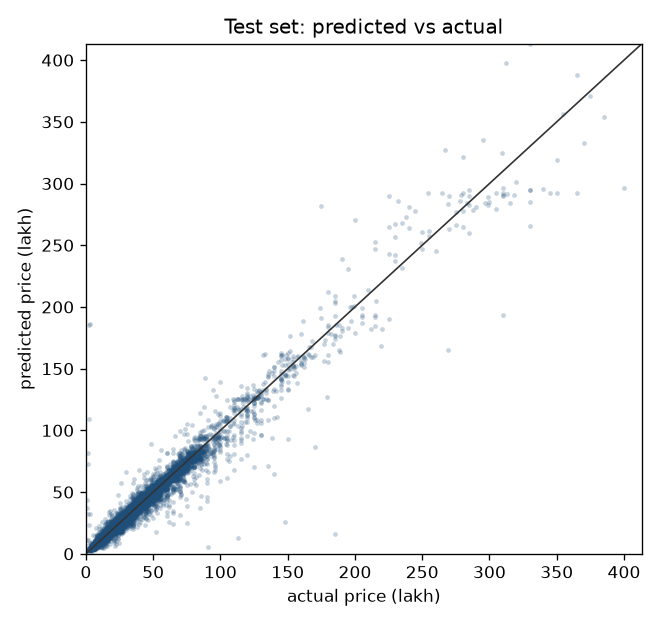

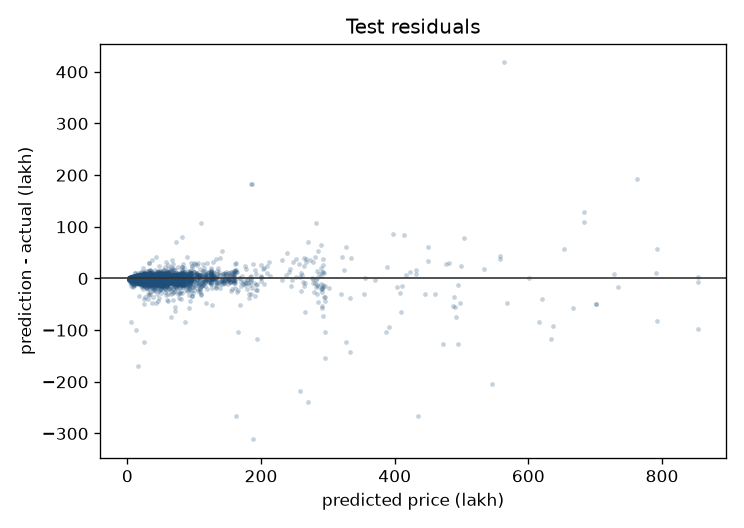

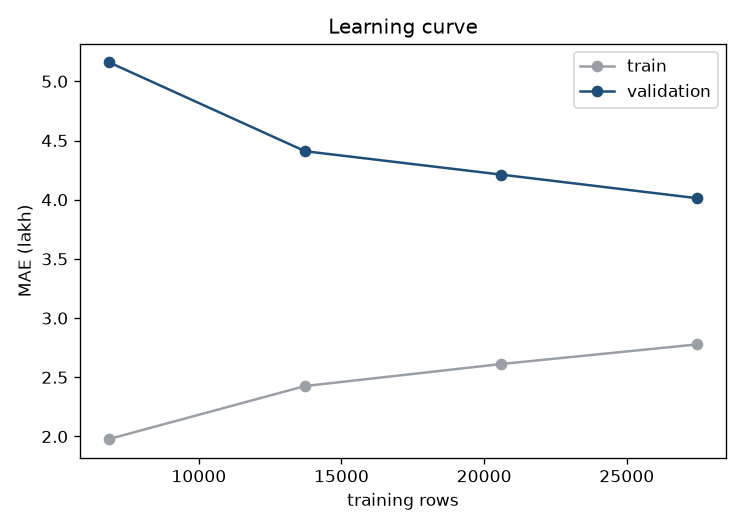

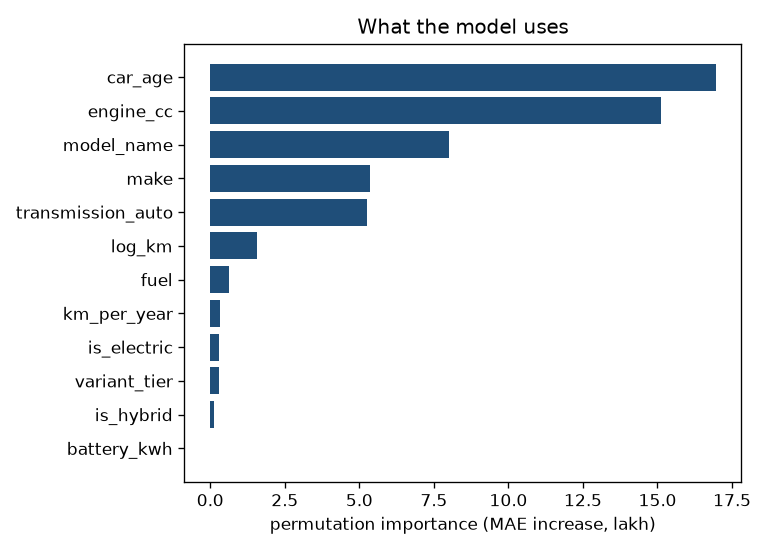

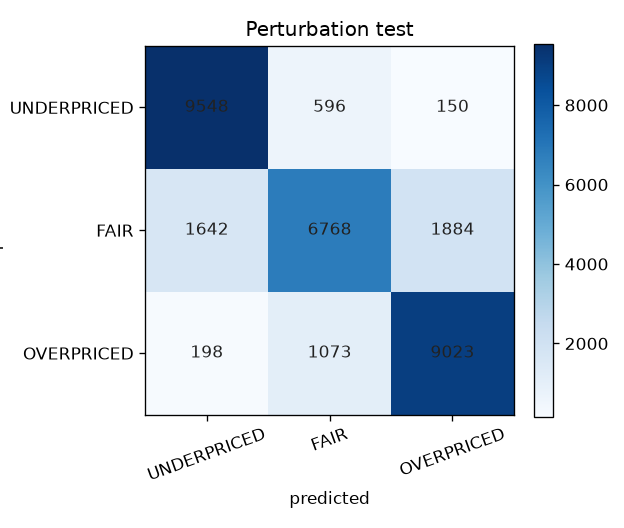

In [7]:
for name in [
    "pred_vs_actual.png",
    "residuals.png",
    "learning_curve.png",
    "permutation_importance.png",
    "confusion_matrix.png",
]:
    display(Image(filename=str(FIGURES / name)))

Residuals fan out as the price rises, which is why the band is a percentage rather than a fixed number of lakh. The learning curve is still falling at the full training size, and training error sits about 1.2 lakh under validation error. Age and engine size move the estimate the most. Make and model still matter after that: a Prado and a Corolla of the same age are not the same car.